In [1]:
# Import the library that lets us download files from a URL
import urllib.request

# This is the direct download link for the dataset (CSV file)
DATA_URL = "https://raw.githubusercontent.com/sachin365123/CSV-files-for-Data-Science-and-Machine-Learning/main/Loan%20Approval%20Prediction.csv"

# The name we will save the file as
FILE_NAME = "loan_approval_data.csv"

# Download the file from the URL and save it in Colab's storage
urllib.request.urlretrieve(DATA_URL, FILE_NAME)

print("Dataset downloaded successfully as:", FILE_NAME)

Dataset downloaded successfully as: loan_approval_data.csv


In [2]:
# Import pandas, the main library used to work with tables of data
import pandas as pd

# Read the CSV file into a pandas DataFrame (a table)
df = pd.read_csv(FILE_NAME)

# Show the first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Print rows and columns
print("Shape of dataset (rows, columns):", df.shape)

# Show column names, data types, and missing value counts
df.info()

Shape of dataset (rows, columns): (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
# Show basic statistics for numeric columns
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
# See how many loans were Approved (Y) vs Rejected (N)
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [6]:
# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Keep charts small
plt.rcParams['figure.figsize'] = (5, 4)

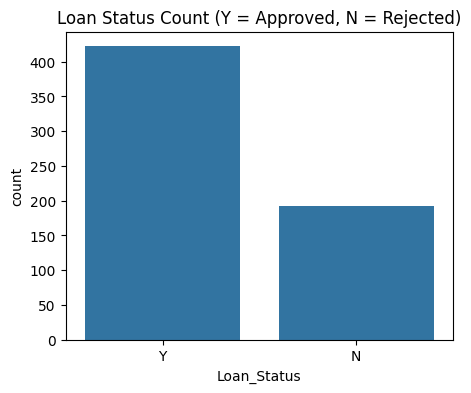

In [7]:
# Loan status counts
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Count (Y = Approved, N = Rejected)")
plt.show()

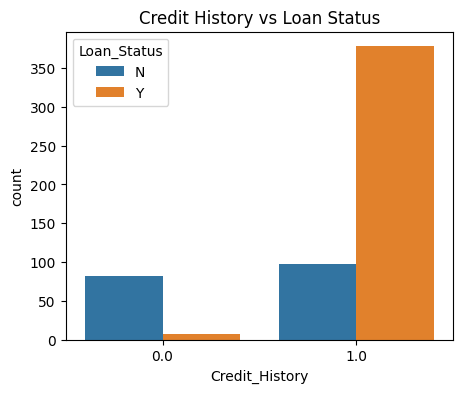

In [8]:
# Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

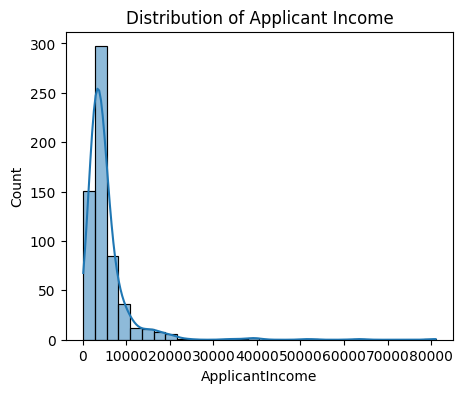

In [9]:
# Applicant income distribution
sns.histplot(df['ApplicantIncome'], kde=True, bins=30)
plt.title("Distribution of Applicant Income")
plt.show()

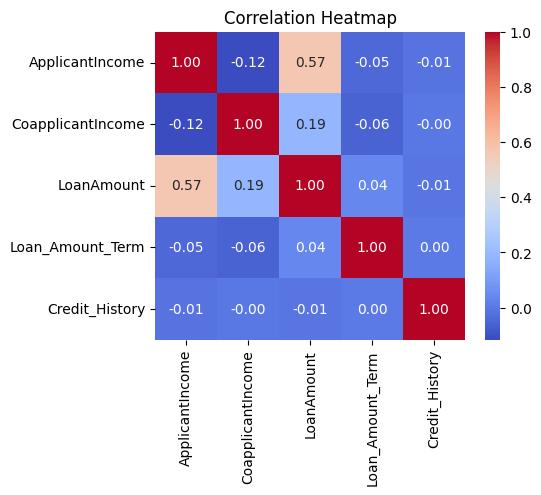

In [10]:
# Correlation heatmap for numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
# Copy the data so the original stays safe
data = df.copy()

# Drop Loan_ID - it's just an ID, not useful for prediction
data = data.drop('Loan_ID', axis=1)

# Fill missing categorical values with the most common value
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Fill missing numeric values with the median
numeric_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

print("Missing values after cleaning:")
print(data.isnull().sum())

Missing values after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder

cols_to_encode = ['Gender', 'Married', 'Dependents', 'Education',
                   'Self_Employed', 'Property_Area', 'Loan_Status']

encoders = {}
for col in cols_to_encode:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [13]:
# X = input columns, y = the column we want to predict
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (614, 11)
y shape: (614,)


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X, y)

selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
print("Selected features:", selected_features)

X = X[selected_features]
X.head()

Selected features: ['Gender', 'Married', 'Education', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


,Gender,Married,Education,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0.0,128.0,360.0,1.0,2
1,1,1,0,1508.0,128.0,360.0,1.0,0
2,1,1,0,0.0,66.0,360.0,1.0,2
3,1,1,1,2358.0,120.0,360.0,1.0,2
4,1,0,0,0.0,141.0,360.0,1.0,2


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Gender,Married,Education,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.472343,-1.372089,-0.528362,-0.554487,-0.211241,0.273231,0.411733,1.223298
1,0.472343,0.728816,-0.528362,-0.038732,-0.211241,0.273231,0.411733,-1.318513
2,0.472343,0.728816,-0.528362,-0.554487,-0.948996,0.273231,0.411733,1.223298
3,0.472343,0.728816,1.892641,0.251980,-0.306435,0.273231,0.411733,1.223298
4,0.472343,-1.372089,-0.528362,-0.554487,-0.056551,0.273231,0.411733,1.223298


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (491, 8)
Test set size: (123, 8)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained successfully")

Logistic Regression trained successfully
Random Forest trained successfully
Support Vector Machine trained successfully


In [18]:
from sklearn.model_selection import cross_val_score

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}: mean accuracy = {scores.mean():.4f}")

Logistic Regression: mean accuracy = 0.7984
Random Forest: mean accuracy = 0.7434
Support Vector Machine: mean accuracy = 0.7963


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1}

    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")

--- Logistic Regression ---
Accuracy:  0.8618
Precision: 0.8400
Recall:    0.9882
F1 Score:  0.9081

--- Random Forest ---
Accuracy:  0.7886
Precision: 0.8391
Recall:    0.8588
F1 Score:  0.8488

--- Support Vector Machine ---
Accuracy:  0.8537
Precision: 0.8317
Recall:    0.9882
F1 Score:  0.9032



In [20]:
comparison_df = pd.DataFrame(results).T
comparison_df['CV Accuracy'] = [cv_results[name] for name in comparison_df.index]
comparison_df = comparison_df.round(4).sort_values(by='F1 Score', ascending=False)

comparison_df

,Accuracy,Precision,Recall,F1 Score,CV Accuracy
Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.7984
Support Vector Machine,0.8537,0.8317,0.9882,0.9032,0.7963
Random Forest,0.7886,0.8391,0.8588,0.8488,0.7434


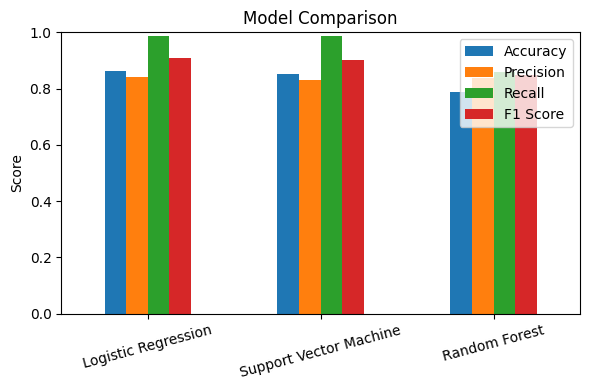

In [21]:
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', figsize=(6, 4))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [22]:
best_model_name = comparison_df['F1 Score'].idxmax()
print("Best performing model:", best_model_name)
print(comparison_df.loc[best_model_name])

Best performing model: Logistic Regression
Accuracy       0.8618
Precision      0.8400
Recall         0.9882
F1 Score       0.9081
CV Accuracy    0.7984
Name: Logistic Regression, dtype: float64
